In [1]:
# !pip install tensorflow

In [21]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install optuna
# !pip install xgboost catboost
# !pip install lightgbm imblearn

In [22]:
import random
import pandas as pd
pd.set_option('display.max_columns', None)
pd.option_context('mode.use_inf_as_na', True)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, roc_curve,
                            roc_auc_score, precision_score,
                            recall_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


import joblib
import optuna

import xgboost as xgb
import lightgbm as lgb
import catboost as cb 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from optuna.samplers import TPESampler
from imblearn.over_sampling import SMOTENC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings("ignore")

In [23]:
df_train = pd.read_csv("./train.csv")
df_test = pd.read_csv("./test.csv")

In [ ]:
print(f"Training data rows: {df_train.shape[0]}, columns: {df_train.shape[1]}")
# print(f"Test data rows: {df_test.shape[0]}, columns: {df_test.shape[1]}")

Training data rows: 58645, columns: 13
Test data rows: 39098, columns: 12


In [25]:
df_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


#### Column Description: 

- `person_age`:  Age of the loan applicant in years.
- `person_income`: Annual income of the applicant.
- `person_home_ownership`: Home ownership status of the applicant. Values are as below....
    - RENT
    - OWN
    - MORTGAGE
    - OTHER
- `person_emp_length`: Length of employment in years.
- `loan_intent`: Purpose of the loan. Values are as below....
    - PERSONAL
    - EDUCATION
    - MEDICAL
    - VENTURE
    - HOMEIMPROVEMENT
    - DEBTCONSOLIDATION
- `loan_grade`: Credit grade assigned to the loan. Values are as below....
    - A,
    - B,
    - C,
    - D,
    - E,
    - F,
    - G
- `loan_amnt`: Amount of loan requested.
- `loan_int_rate`: Interest rate charged on the loan.
- `loan_percent_income`: Percentage of the applicant’s income used to repay the loan.
- `cb_person_default_on_file`: Indicates whether the applicant has defaulted previously. Values are as below....
    - Y → Yes
    - N → No
- `cb_person_cred_hist_length`: Length of credit history in years.
- `loan_status` 🎯 (Target Variable). Values are as below....
    - 0 → Loan rejected / default
    - 1 → Loan approved / no default


In [26]:
df_train.isna().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [27]:
df_test.isna().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [28]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [29]:
df_train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


#### Categorical columns:
- person_home_ownership,
- loan_intent,
- loan_grade,
- cb_person_default_on_file

#### Ordinal encoding recommended:
- loan_grade

In [30]:
df_train.person_home_ownership.value_counts()

person_home_ownership
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64

In [31]:
df_train.loan_intent.value_counts()

loan_intent
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64

In [32]:
df_train.loan_grade.value_counts()

loan_grade
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: count, dtype: int64

In [33]:
df_train.cb_person_default_on_file.value_counts()

cb_person_default_on_file
N    49943
Y     8702
Name: count, dtype: int64

#### Distribution of `Loan Status`

In [34]:
df_count = df_train.groupby(['loan_status'])["id"].aggregate({'count'}).reset_index().sort_values(by='count', ascending=False)

In [35]:
df_count

,loan_status,count
0,0,50295
1,1,8350


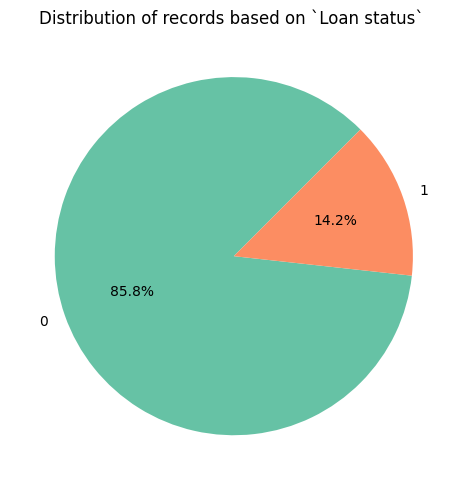

In [36]:
plt.subplots(1, 1, figsize=(12, 5))
plt.subplot(1, 1, 1) 
plt.pie(df_count['count'], labels=df_count['loan_status'], autopct='%1.1f%%', colors=plt.cm.Set2.colors,startangle=45)
plt.title(f'Distribution of records based on `Loan status` ')
plt.tight_layout()

#### Insights:

- Based on data, There are 85.8% records didn't get load approval
- Based on data, There are 14.2% records got load approval

#### Distribution of `Person Age` based on `Loan Status` 

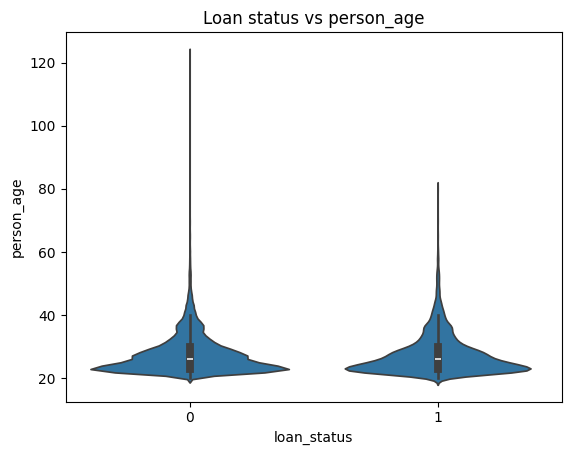

In [37]:
sns.violinplot(x='loan_status',y='person_age',data=df_train)
plt.title(f'Loan status vs person_age')
plt.show()

Insights:

- As you can see `Person Age` column have outliers in both cases (loan_status 0 or 1)
- Most of the `Person Age` lies beteen 20 to 40

#### Distribution of `Person Income` based on `Loan Status` 

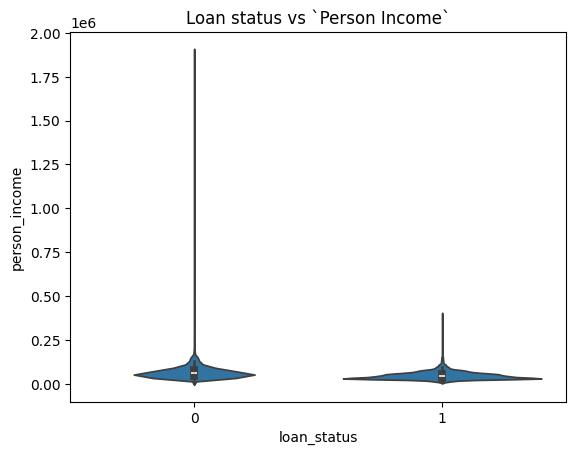

In [38]:
sns.violinplot(x='loan_status',y='person_income',data=df_train)
plt.title(f'Loan status vs `Person Income`')
plt.show()

#### Insights:

- Clearly visible `Person Income` column have outliers in both cases (loan_status 0 or 1)

#### Distribution of `Home Ownership`

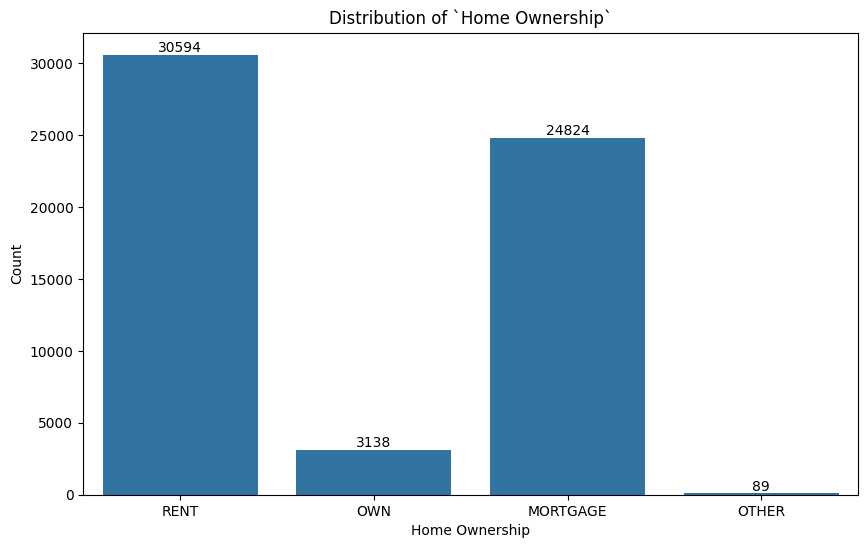

In [39]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="person_home_ownership")
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of `Home Ownership`")
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.show()

#### Insights:

-  There are 4 types of `person_home_ownership` as below.
    - Rent (52.16%)
    - Mortgage (42.32%)
    - Own (05.35%)
    - Other (00.15%)

-  As we can see `94.48%` of data belongs to `Rent` and `OWN`

#### Loan Status based on `Home Ownership`

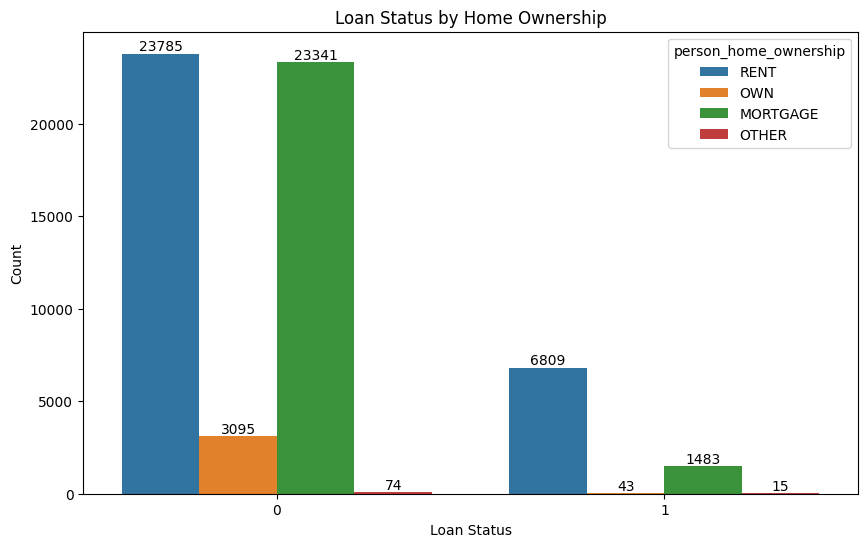

In [40]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_status", hue='person_home_ownership')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Loan Status by Home Ownership")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### Insights:

-  Distribution of Loas Status based on `person_home_ownership`
-  There are 4 types of `person_home_ownership` as below.
    - Rent
    - Own
    - Mortgage
    - Other
- In case of `loas_status` = 0, 46.4% of people prefer `MORTGAGE`, 47.2% people prefer `RENT`
- In case of `loas_status` = 1, 81.5% of people prefer `RENT`, 17.7% people prefer `MORTGAGE`

#### Distribution of `Person Employment Length` based on `Loan Status` 

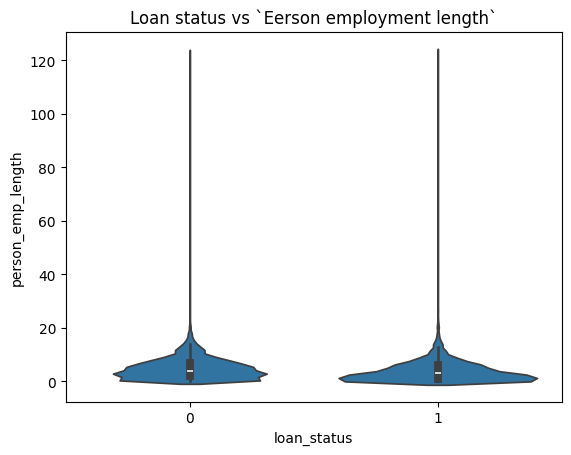

In [41]:
sns.violinplot(x='loan_status',y='person_emp_length',data=df_train)
plt.title(f'Loan status vs `Eerson employment length`')
plt.show()

#### Insights:

- Clearly visible `Person Employment Length` column have outliers in both cases (loan_status 0 or 1)
- Most of the values for `Person Employment Length` lies between 0 to 16

#### Distribution of `Loan Intent` 

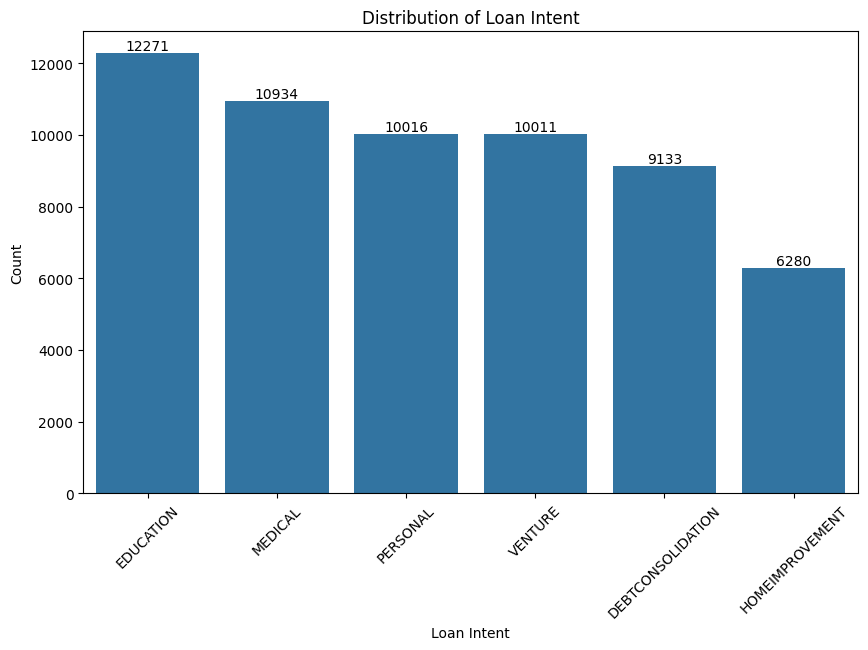

In [42]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_intent")
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Insights:

- There are 20.92% data points for `loan_intent` -> `Education`,
- 18.64% data points for `loan_intent` -> `Medical`,
- 17.08% data points for `loan_intent` -> `Personal`,
- 17.07% data points for `loan_intent` -> `Venture`,
- 15.57% data points for `loan_intent` -> `DEBTCONSOLIDATION`,
- 10.7%  data points for `loan_intent` -> `HOMEIMPROVEMENT`,

#### Distribution of `Loan amount` based on `Loan Intent` 

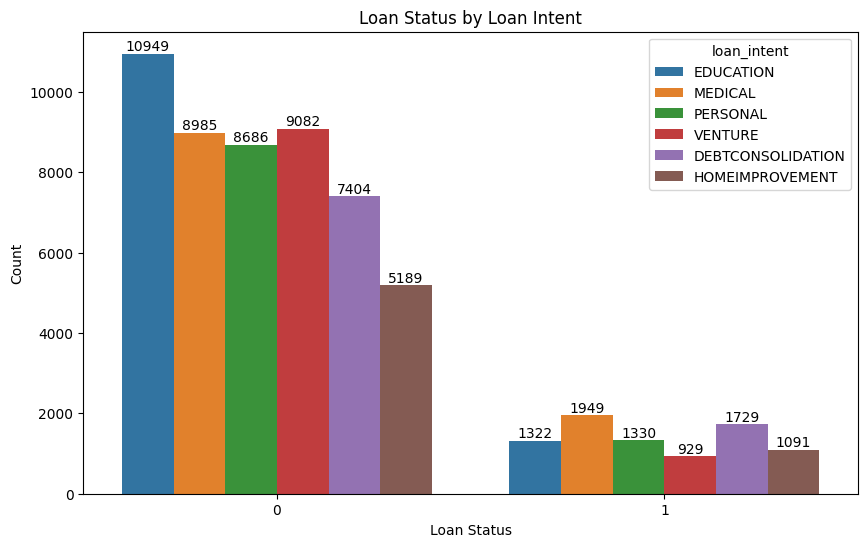

In [43]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_status", hue='loan_intent')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Loan Status by Loan Intent")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### Insights:

- Based on given data,
    - There are `23.34%` chances for `loan_intent` -> `Medical` for loan approval
    - And  there are `20.7%` chances for `loan_intent` -> `DEBTCONSOLIDATION` for loan approval
    - And  there are `15.9%` chances for `loan_intent` -> `PERSONAL` for loan approval
    - And  there are `15.8%` chances for `loan_intent` -> `EDUCATION` for loan approval
    - And  there are `13.0%` chances for `loan_intent` -> `HOMEIMPROVEMENT` for loan approval
    - And  there are `11.12%` chances for `loan_intent` -> `VENTURE` for loan approval
- Based on given data,
    - There are `21.76%` data points for `loan_intent` -> `EDUCATION` for loan not approved
    - And  there are `18.05%` data points  for `loan_intent` -> `VENTURE` for loan not approved
    - And  there are `17.8%` data points  for `loan_intent` -> `MEDICAL` for loan not approved
    - And  there are `17.2%` data points  for `loan_intent` -> `PERSONAL` for loan not approved
    - And  there are `14.7%` data points  for `loan_intent` -> `DEBTCONSOLIDATION` for loan not approved
    - And  there are `10.1%` data points  for `loan_intent` -> `HOMEIMPROVEMENT` for loan not approved

#### Distribution of Loan Grade

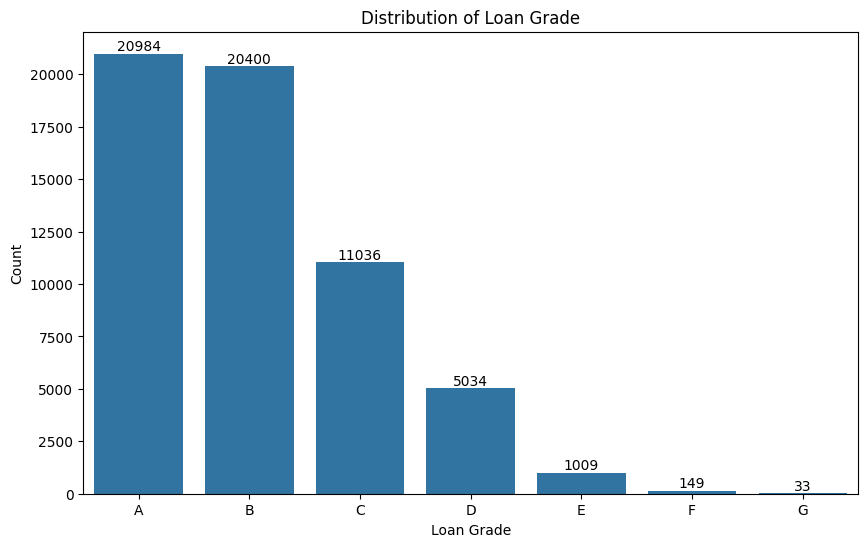

In [44]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_grade", order=df_train['loan_grade'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.show()

#### Insights:

- There are 7 categories of `loan grade`
    - `A` class have 35.78% data points
    - `B` class have 34.78% data points
    - `C` class have 18.81% data points
    - `D` class have 08.58% data points
    - `E` class have 01.72% data points
    - `F` class have  0.25% data points
    - `G` class have  0.05% data points
- `Loan grade` `A`, `B`, `C` have almost `88%` of data points

#### Distribution of `Loan grade` based on `Loan Status` 

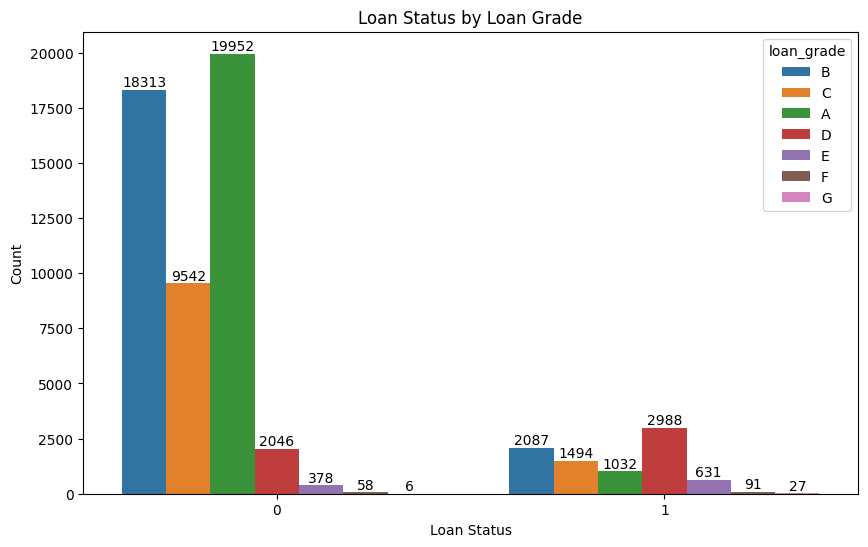

In [45]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_status", hue='loan_grade')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Loan Status by Loan Grade")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### Insights:

- There are 35.78% of data belongs to `D` class in case of loan_status = 1
- There are 24.99% of data belongs to `B` class in case of loan_status = 1
- There are 17.89% of data belongs to `C` class in case of loan_status = 1
- There are 12.35% of data belongs to `A` class in case of loan_status = 1

- There are 39.66% of data belongs to `A` class in case of loan_status = 0
- There are 36.41% of data belongs to `B` class in case of loan_status = 0
- There are 38.97% of data belongs to `C` class in case of loan_status = 0
- Class `D`, `E`, `F`, `G` have almost `5%` of data in case of loan_status = 0

#### Distribution of `cb_person_default_on_file`

In [46]:
(df_train.groupby(['cb_person_default_on_file']).size()/len(df_train))*100

cb_person_default_on_file
N    85.161565
Y    14.838435
dtype: float64

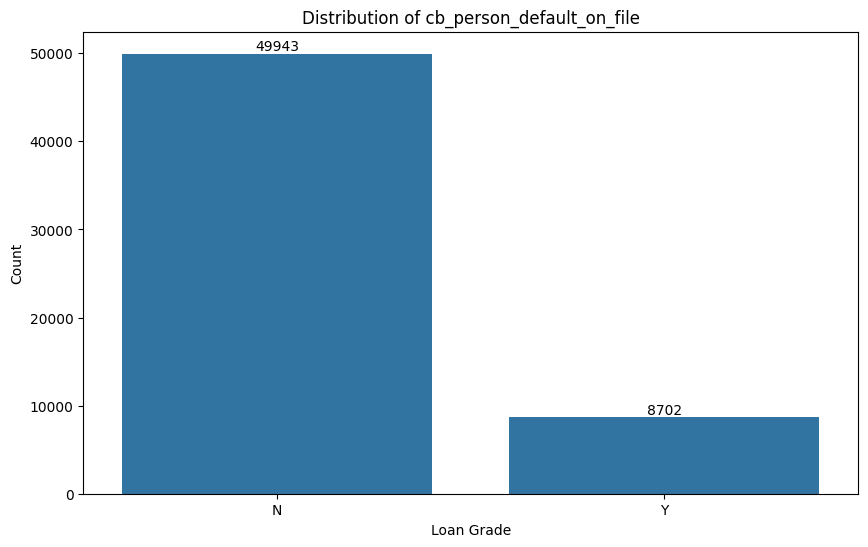

In [47]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="cb_person_default_on_file", order=df_train['cb_person_default_on_file'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of cb_person_default_on_file")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.show()

#### Insights:

- There are `85.16%` people which are not defaulted previously.
  There are `14.83%` people which are defaulted previously.

#### Distribution of `cb_person_default_on_file` based on `Loan Status` 

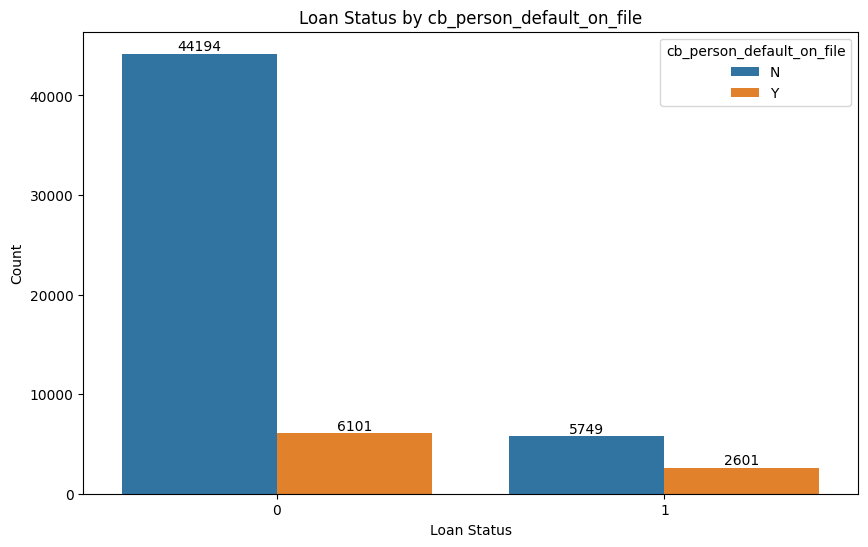

In [48]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(df_train, x="loan_status", hue='cb_person_default_on_file')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Loan Status by cb_person_default_on_file")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### Insights:

- There are `12.13%` of data points not defaulted in case of `loan_status = 0`
- There are `87.86%` of data points defaulted in case of `loan_status = 0`

- There are `68.85%` of data points not defaulted in case of `loan_status = 1`
- There are `31.14%` of data points defaulted in case of `loan_status = 1`

In [49]:
#(df_train[df_train['loan_status'] == 0].groupby(['cb_person_default_on_file']).size()/len(df_train[df_train['loan_status'] == 0]))*100

In [50]:
#(df_train[df_train['loan_status'] == 1].groupby(['cb_person_default_on_file']).size()/len(df_train[df_train['loan_status'] == 1]))*100

#### Distribution of `Loan amount` based on `Loan Status` 

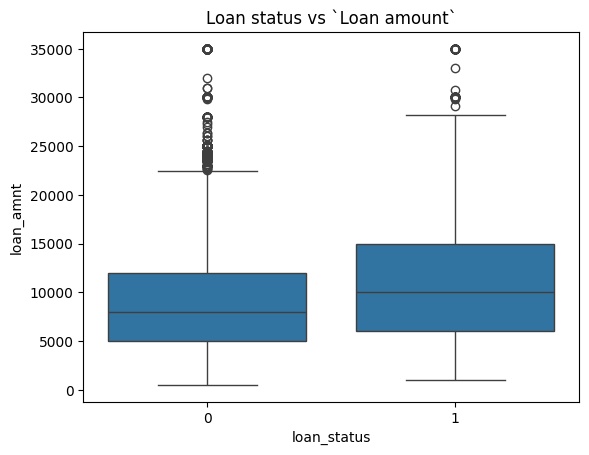

In [51]:
sns.boxplot(x='loan_status',y='loan_amnt',data=df_train)
plt.title(f'Loan status vs `Loan amount`')
plt.show()

#### Insights:

- Clearly visible `Person amount` column have outliers in both cases (loan_status 0 or 1)
- In case of loan_status = 0, mots of the `Person amount` lies between 5000 to 12000
- In case of loan_status = 1, mots of the `Person amount` lies between 6000 to 15000

#### Distribution of `Loan interest rate` based on `Loan Status` 

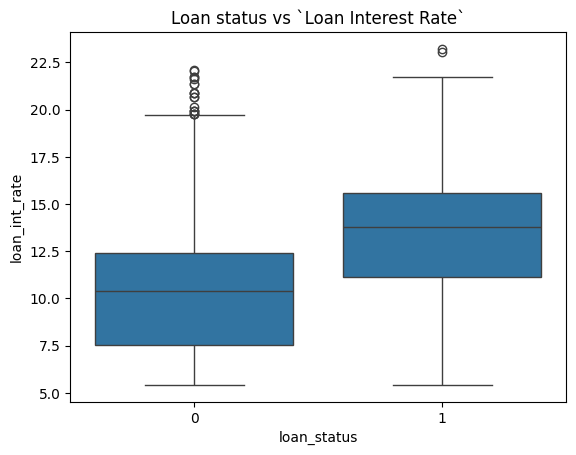

In [52]:
sns.boxplot(x='loan_status',y='loan_int_rate',data=df_train)
plt.title(f'Loan status vs `Loan Interest Rate`')
plt.show()

#### Insights:

- Clearly visible `loan_int_rate` column have outliers in both cases (loan_status 0 or 1)
- In case of loan_status = 0, most of the `Loan interest rate` lies between `7.5%` to `12.5%`
- In case of loan_status = 1, most of the `Loan interest rate` lies between `11%` to `15%`

#### Distribution of `Loan percent income` based on `Loan Status` 

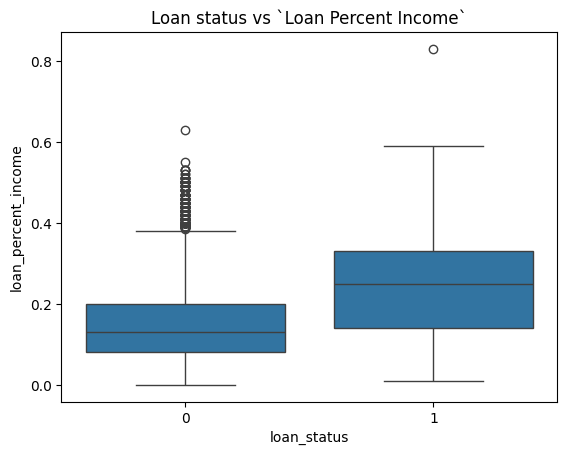

In [53]:
sns.boxplot(x='loan_status',y='loan_percent_income',data=df_train)
plt.title(f'Loan status vs `Loan Percent Income`')
plt.show()

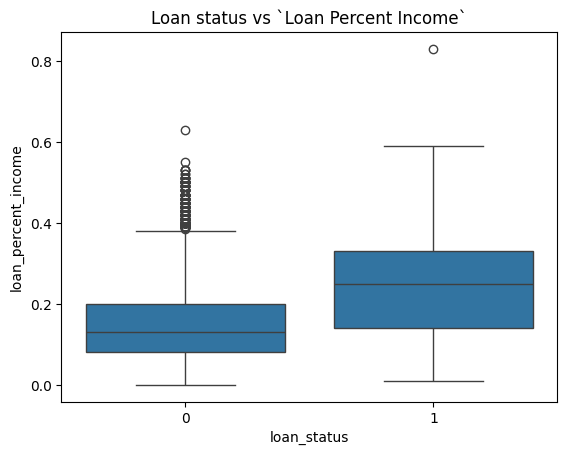

In [54]:
sns.boxplot(x='loan_status',y='loan_percent_income',data=df_train)
plt.title(f'Loan status vs `Loan Percent Income`')
plt.show()

#### Insights:

- Clearly visible `loan_percent_income` column have outliers for loan_status = 0, loan_status = 1 have very less or none
- In case of loan_status = 0, most of the `loan_percent_income` lies between `0.1%` to `0.2%`
- In case of loan_status = 1, most of the `loan_percent_income` lies between `0.15%` to `0.3%`

- Clearly visible for most of the loan approved where `loan_percent_income` is higher.

#### Distribution of `cb_person_cred_hist_length` based on `Loan Status` 

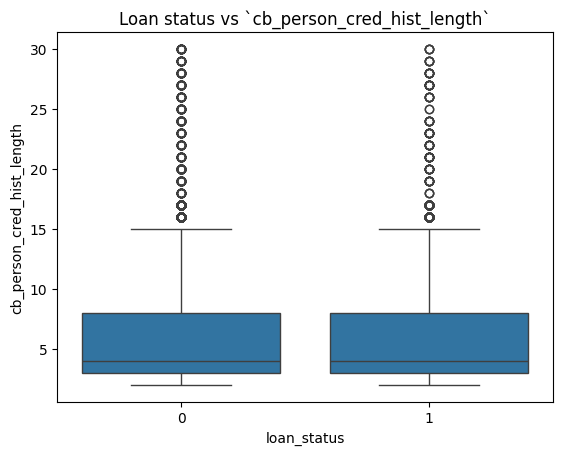

In [55]:
sns.boxplot(x='loan_status',y='cb_person_cred_hist_length',data=df_train)
plt.title(f'Loan status vs `cb_person_cred_hist_length`')
plt.show()

#### Insights:

- Clearly visible `cb_person_cred_hist_length` column have outliers in both cases (loan_status 0 or 1)
